In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from backtester.market import MarketDataFromCSV


/Users/nick/Documents/www/alphakit
Asset cumulative Performance: 2327.9617203827984  %
Asset simple Performance: 2327.9617203827966  %
Strategy cumulative Performance (simple): 3800.3126489670803  %


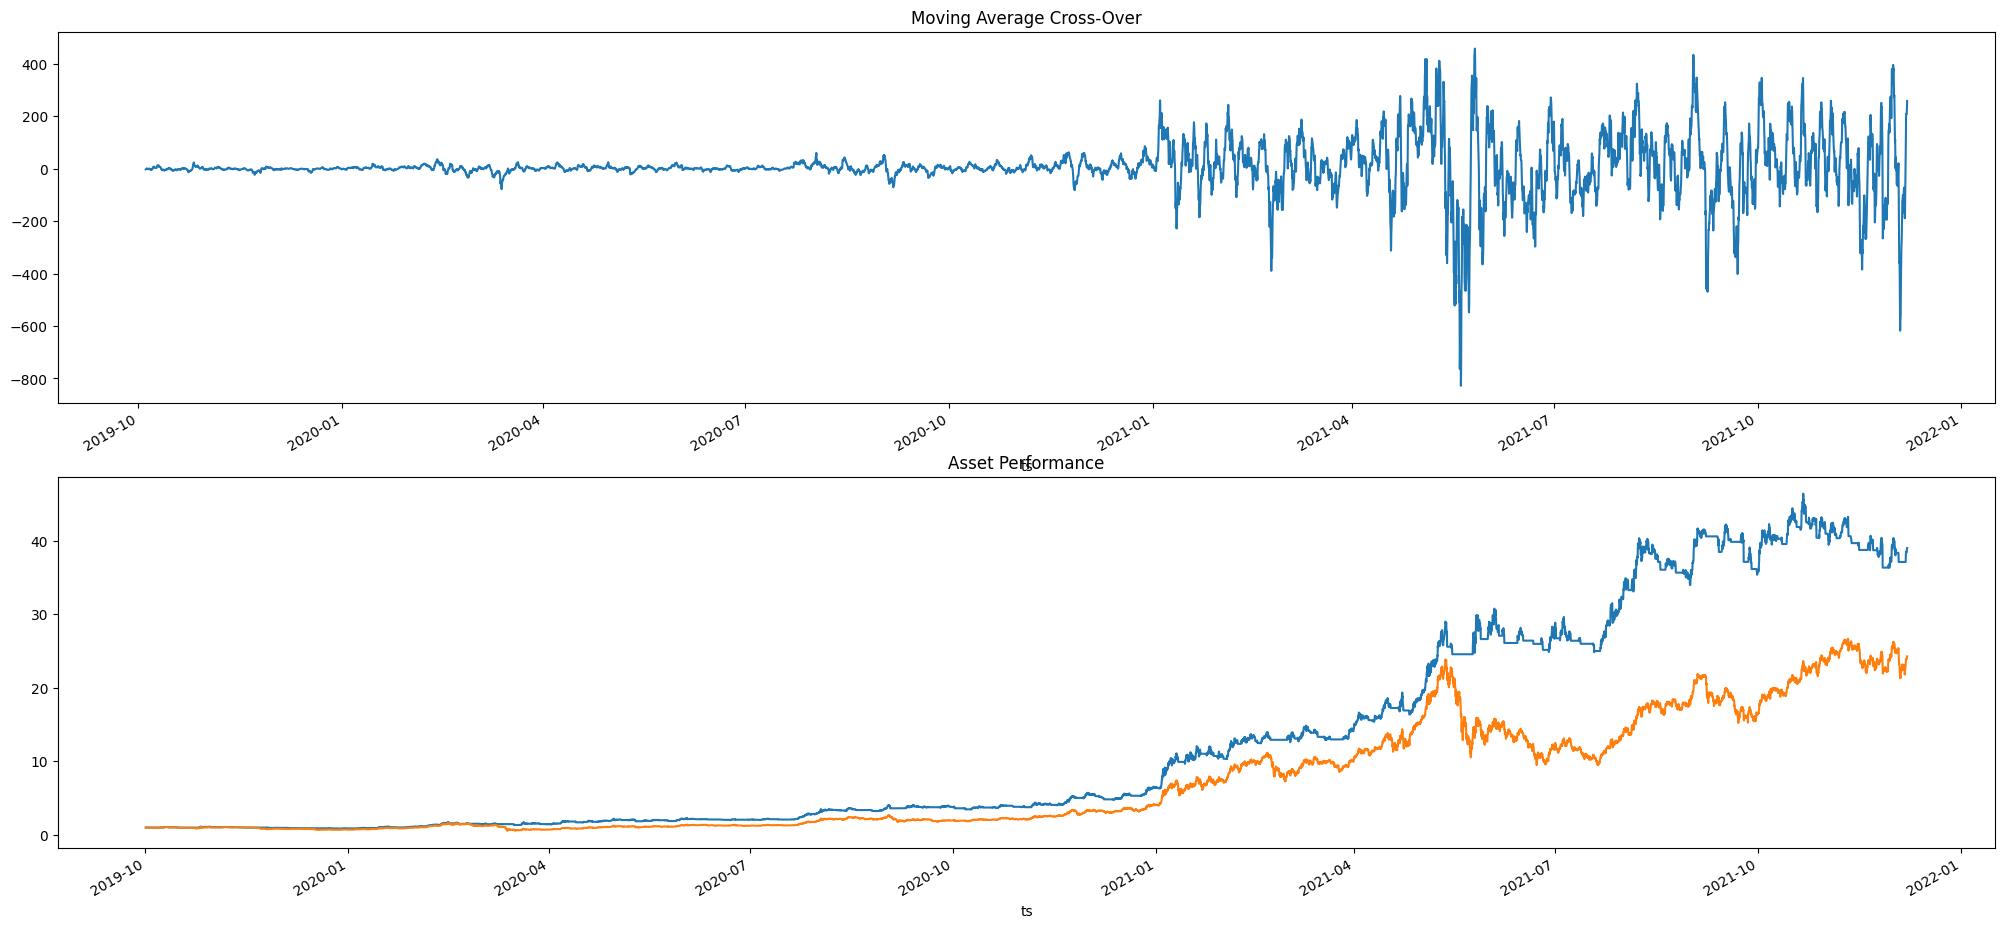

In [2]:
# prices is a pandas series with time as an index
######################################################################################################

INTERVAL=2
UNIT_OF_TIME='hour'

SLOW_MA=42
FAST_MA=2


DATE_FROM="2019-10-01"
DATE_TO="2022-02-10"

SYMBOL='ETH-PERP/USD'

SIDE='long'

######################################################################################################
cwd = os.getcwd()
print(cwd)

df = MarketDataFromCSV(symbol=SYMBOL,
                        date_from=DATE_FROM,
                        date_to=DATE_TO,
                        interval=INTERVAL,
                        unit_of_time=UNIT_OF_TIME,
                        path=f"{cwd}/datasets/COINBASE_ETHUSD_2H.csv").get_df()
prices = df['close']

# Compute the log-returns of the underlying asset.
# https://investmentcache.com/magic-of-log-returns-concept-part-1/
rs = prices.apply(np.log).diff(1)


# compute signals (ma diff)
w1 = FAST_MA # short-term moving average window
w2 = SLOW_MA # long-term moving average window
ma_x = prices.rolling(w1).mean() - prices.rolling(w2).mean()

def backtest_side(val, side):
    if(side == 'both'):
        return np.sign(val)
    if(side == 'long'):
        if(val > 0):
            return 1;
        else:
            return 0;
    if(side == 'short'):
        if(val < 0):
            return -1;
        else:
            return 0;


# compute positions based on signals
pos = ma_x.apply(backtest_side, args=(SIDE,)).shift(0) # +1 if long, -1 if short


# tweak prot figure size for better readability
plt.rcParams["figure.figsize"] = (25,12)

fig, ax = plt.subplots(2,1)

ma_x.plot(ax=ax[0], title='Moving Average Cross-Over')
# compute positions based on signals
pos = ma_x.apply(backtest_side, args=(SIDE,)) # +1 if long, -1 if short

# returns - we need to shift by 1 as we are opening and closing positions after crossing confirmation
my_rs = pos.shift(1)*rs

# cumulative performance
my_rs.cumsum().apply(np.exp).plot(title='Strategy Performance')
rs.cumsum().apply(np.exp).plot(title='Asset Performance')

print("Asset cumulative Performance:", (rs.cumsum().apply(np.exp).iat[-1] - 1) * 100, " %")
# simple returns = close/open - 1
print("Asset simple Performance:", ((prices.iat[-1] / prices.iat[0]) - 1) * 100, " %")

print("Strategy cumulative Performance (simple):", (my_rs.cumsum().apply(np.exp).iat[-1] - 1) * 100, " %")


pd.set_option('display.max_rows', 500)

result_df = pd.DataFrame({
    "close_prices": prices,
    "my_rs": my_rs.cumsum().apply(np.exp),
    "rs": rs.cumsum().apply(np.exp),
    "pos": pos,
    "prev_pos": pos.shift(1)
})

# extract buy and sell signals with dates
result_df['signal_buy'] = ((result_df['pos'] == 1) & (result_df['prev_pos'] == 0))
result_df['signal_sell'] = ((result_df['pos'] == 0) & (result_df['prev_pos'] == 1))



# result_df[(result_df['signal_buy'] == True) | (result_df['signal_sell'] == True)]

In [3]:
def execute_wrapped_backtest(params, df):
    prices = df['close']

    # log returns of the asset
    rs = prices.apply(np.log).diff(1)

    # params
    w1 = params['short_ma']
    w2 = params['long_ma']
    fee_rate = 0.005  # 0.5% per side

    # signal: MA diff
    ma_x = prices.rolling(w1).mean() - prices.rolling(w2).mean()

    # position: backtest_side should return {-1,0,+1} (or {0,1} for long-only)
    pos = ma_x.apply(backtest_side, args=(SIDE,))

    # execute on next bar
    pos_exec = pos.shift(1).fillna(0)

    # strategy log returns (before fees)
    strat_rs = pos_exec * rs

    # ---- fees: charge when position changes ----
    # Δpos: +1 enter long, -1 exit long (or enter short), ±2 flip
    dpos = pos_exec.diff().fillna(pos_exec)  # first trade from 0→pos0 if any
    units_traded = dpos.abs()

    # per-side fee in log space: log(1 - fee_rate) (negative)
    fee_log_per_unit = np.log1p(-fee_rate)
    fee_rs = units_traded * fee_log_per_unit  # flip ⇒ 2 * fee

    # net strategy log returns
    net_rs = strat_rs + fee_rs

    asset_perf = np.exp(rs.cumsum()).iat[-1] - 1
    algo_perf  = np.exp(net_rs.cumsum()).iat[-1] - 1

    return {
        "long_ma": w2,
        "short_ma": w1,
        "asset_performance": asset_perf,
        "algo_performance": algo_perf
    }


def multiprocessing_wrapper(paramset):
    params = {
    "long_ma": paramset[0],
    "short_ma": paramset[1],
    }

    return execute_wrapped_backtest(params=params, df=df)

In [4]:
##### Execute with multiprocessing
# from multiprocessing import Pool
import itertools as it

import multiprocess as mp
from tqdm import tqdm

# define ranges for long and short MA window lengths
long_ma_length=range(2, 1000, 10)
short_ma_length=range(2, 300, 5)

values={
    "long_ma": long_ma_length,
    "short_ma": short_ma_length
}

# create all possible combinations
combinations = list(it.product(*list(values.values())))

# how many threads used + max tasks per child is used to restart child process after this many tasks processed so we don't start running out or ram
pool = mp.Pool(5, maxtasksperchild=50)

backtesting_results = list(tqdm(pool.imap(multiprocessing_wrapper, combinations,), total=len(combinations)))

# close multiprocessing pool once finished
pool.close()

pd.DataFrame(backtesting_results).sort_values(by=['algo_performance'], ascending=False)

100%|██████████| 6000/6000 [00:04<00:00, 1208.42it/s]


,long_ma,short_ma,asset_performance,algo_performance
1719,282,197,23.279617,31.262831
1528,252,142,23.279617,28.781141
2611,432,157,23.279617,27.994073
1587,262,137,23.279617,27.647116
1894,312,172,23.279617,27.361083
...,...,...,...,...
5,2,27,23.279617,-0.961220
4,2,22,23.279617,-0.980101
3,2,17,23.279617,-0.986082
2,2,12,23.279617,-0.996377


In [5]:
pd.DataFrame(backtesting_results).sort_values(by=['algo_performance'], ascending=False).head(50)

,long_ma,short_ma,asset_performance,algo_performance
1719,282,197,23.279617,31.262831
1528,252,142,23.279617,28.781141
2611,432,157,23.279617,27.994073
1587,262,137,23.279617,27.647116
1894,312,172,23.279617,27.361083
1718,282,192,23.279617,26.844992
2551,422,157,23.279617,26.700075
1776,292,182,23.279617,26.591994
1717,282,187,23.279617,26.543075
1896,312,182,23.279617,26.396370


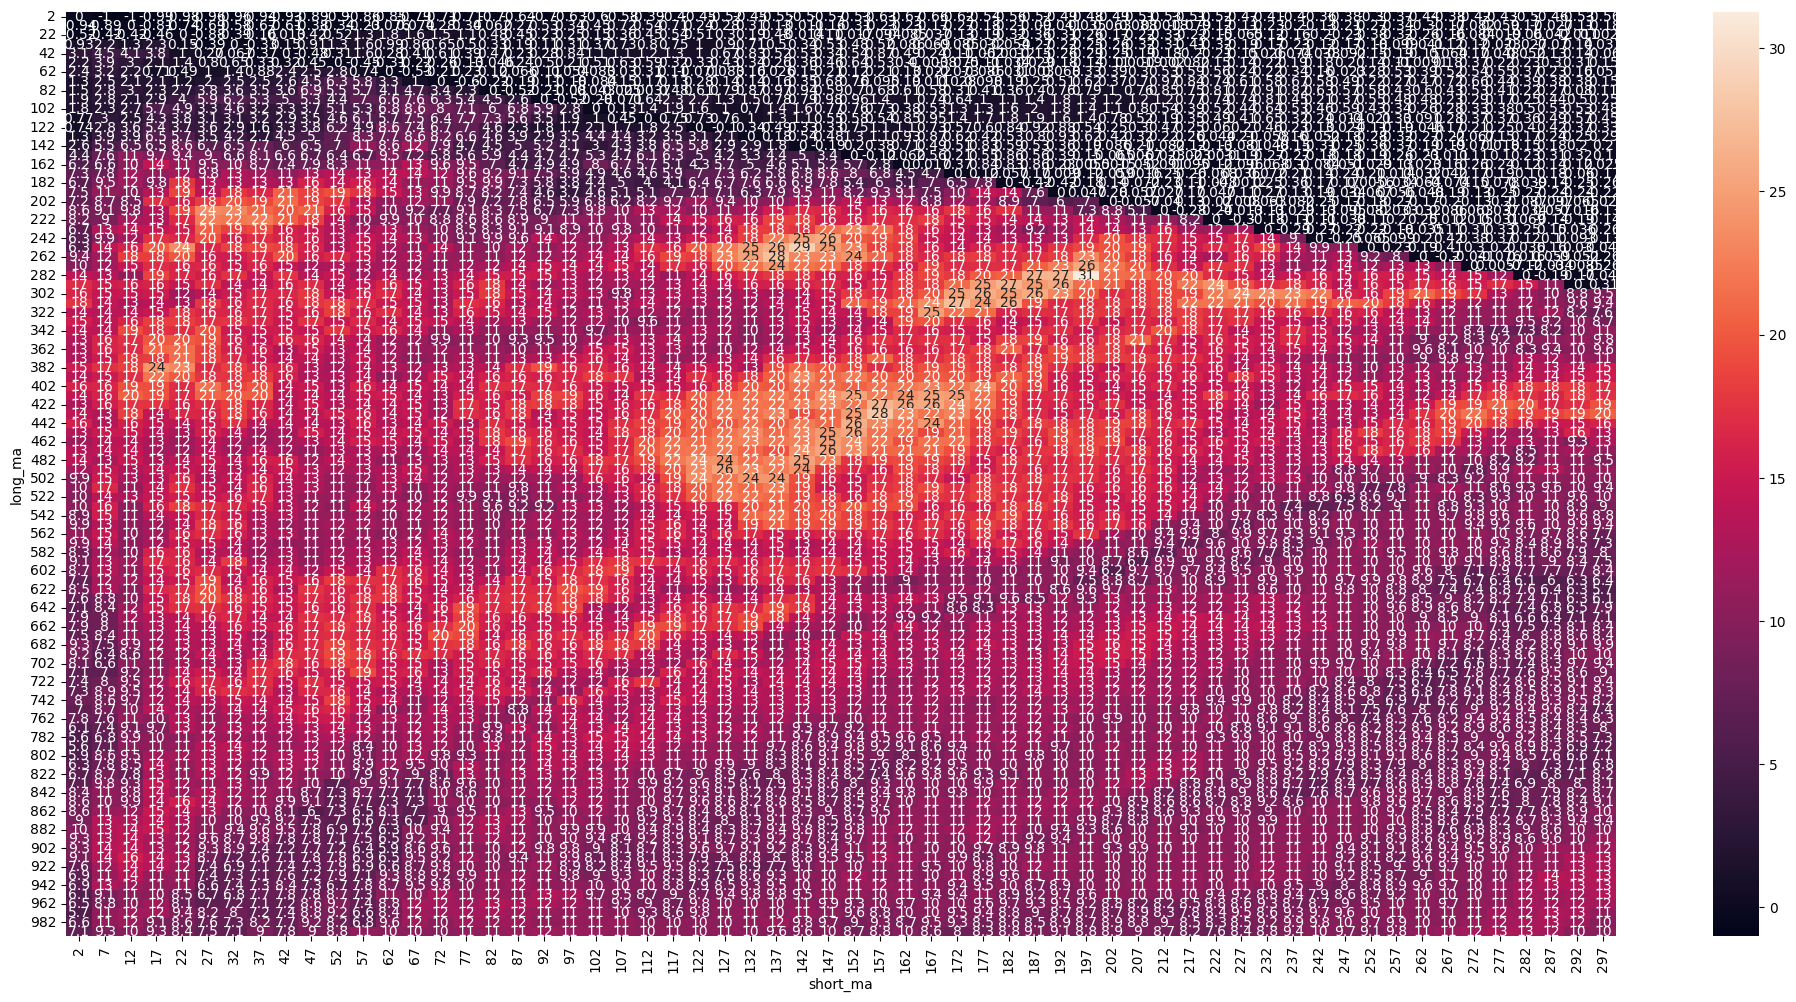

In [6]:
results = pd.DataFrame(backtesting_results)

results2  = results.copy()

# pivot table used for the heatmaps
results2 = results2.pivot(index='long_ma', columns='short_ma', values='algo_performance')
# construct the heatmap with seaborn
sns.heatmap(results2, annot=True)

results.to_pickle("./vectorized-optimization-results-pickled.pkl")

In [7]:
import plotly.graph_objects as go



# load dataset
df = results2

# create figure
fig = go.Figure()

# Add surface trace
fig.add_trace(go.Surface(z=df.values.tolist(), colorscale="Viridis"))

# Update plot sizing
fig.update_layout(
    width=800,
    height=900,
    autosize=False,
    margin=dict(t=0, b=0, l=0, r=0),
    template="plotly_white",
)

# Update 3D scene options
fig.update_scenes(
    aspectratio=dict(x=1, y=1, z=0.7),
    aspectmode="manual"
)

# Add dropdown
fig.update_layout(
    updatemenus=[
        dict(
            type = "buttons",
            direction = "left",
            buttons=list([
                dict(
                    args=["type", "surface"],
                    label="3D Surface",
                    method="restyle"
                ),
                dict(
                    args=["type", "heatmap"],
                    label="Heatmap",
                    method="restyle"
                )
            ]),
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.11,
            xanchor="left",
            y=1.1,
            yanchor="top"
        ),
    ]
)

# Add annotation
fig.update_layout(
    annotations=[
        dict(text="Trace type:", showarrow=False,
                             x=0, y=1.08, yref="paper", align="left")
    ]
)

fig.show()